In [31]:
import os
import pandas as pd
import torch
import torch.nn as nn
import timm
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

torch.backends.cudnn.benchmark = True

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
class AIGenDetDataset(Dataset):

    def __init__(self, shard_path, transform=None):

        self.shard_path = shard_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(shard_path, "labels.csv")
        )

        print(f"Loaded {len(self.labels)} images")


    def __len__(self):
        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        img_path = os.path.join(
            self.shard_path,
            "images",
            row["image_name"]
        )

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label"]).long()

        return image, label

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(380),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(0.1,0.1,0.1,0.05),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize(400),
    transforms.CenterCrop(380),
    transforms.ToTensor(),
])

In [5]:
import os

print(os.path.exists("/home/daniel"))
print(os.path.exists("/home/daniel/datasets"))
print(os.path.exists("/home/daniel/datasets/ai-gen"))

False
False
False


In [6]:
# DATASET_PATH = "/mnt/c/Development/ai-gen-detection/shard_0/shard_0"
DATASET_PATH = "/workspace/datasets/ai-gen/mnt/c/Development/ai-gen-detection/shard_0/shard_0"

dataset = AIGenDetDataset(
    DATASET_PATH
)

Loaded 50000 images


In [7]:
img, label = dataset[0]

print("Image shape:", img.size)
print("Label:", label)

Image shape: (3456, 2736)
Label: tensor(0)


In [8]:
# import time

# start = time.time()

# for i in range(2000):
#     _ = dataset[i]

# print("Time:", time.time() - start)

In [9]:
# Create custom dataset classes for train and val with proper transforms
class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label
    
    def __len__(self):
        return len(self.subset)

indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.1,
    random_state=42,
    stratify=dataset.labels["label"]
)

# Create subsets and wrap with proper transforms
train_subset = torch.utils.data.Subset(dataset, train_idx)
val_subset = torch.utils.data.Subset(dataset, val_idx)

train_dataset = TransformedDataset(train_subset, train_transform)
val_dataset = TransformedDataset(val_subset, val_transform)

In [10]:
BATCH_SIZE = 16  # Optimized for RTX 4060 laptop (8GB VRAM)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,      # Multi-worker data loading for better performance
    pin_memory=True,
    prefetch_factor=2   # Prefetch 2 batches per worker
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,  # Can use larger batch for validation (no gradients)
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=2
)

In [11]:
# %pip install --upgrade filelock

In [12]:
model = timm.create_model(
    "efficientnet_b4",
    pretrained=True,
    num_classes=2
)

model = model.to(device)

# model = torch.compile(model)

In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Add learning rate scheduler for better convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5,
    eta_min=1e-6
)

scaler = torch.cuda.amp.GradScaler()

In [33]:
# Clear GPU cache and check memory before training setup
torch.cuda.empty_cache()

print("=== GPU Memory Status ===")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
print(f"Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
print(f"Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1024**3:.2f} GB")

=== GPU Memory Status ===
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Total VRAM: 8.00 GB
Allocated: 0.28 GB
Reserved: 0.56 GB
Free: 7.44 GB


In [36]:
def train_epoch(loader):

    model.train()

    running_loss = 0

    for images, labels in tqdm(loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()

        with torch.amp.autocast('cuda'):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

In [37]:
def validate(loader, return_details=False):

    model.eval()

    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(images)

            preds = torch.argmax(outputs, dim=1)
            probs = torch.softmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            if return_details:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    accuracy = correct / total
    
    if return_details:
        return accuracy, all_preds, all_labels, all_probs
    return accuracy

In [18]:
EPOCHS = 5

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_epoch(train_loader)

    val_acc = validate(val_loader)

    print("Train Loss:", train_loss)
    print("Validation Accuracy:", val_acc)
    print("Learning Rate:", optimizer.param_groups[0]['lr'])
    print(f"GPU Memory: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    
    # Step the scheduler
    scheduler.step()
    
    # Clear cache after each epoch
    torch.cuda.empty_cache()


Epoch 1/5


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [01:17<00:00,  2.03it/s]


Train Loss: 0.27100760726754114
Validation Accuracy: 0.9548
Learning Rate: 0.0003
GPU Memory: 0.28 GB

Epoch 2/5


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [01:13<00:00,  2.13it/s]


Train Loss: 0.15416599922160257
Validation Accuracy: 0.9582
Learning Rate: 0.0002714480406590546
GPU Memory: 0.28 GB

Epoch 3/5


...

Train Loss: 0.10642446386583157
Validation Accuracy: 0.9618
Learning Rate: 0.00019669804065905458
GPU Memory: 0.28 GB

Epoch 4/5


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [01:12<00:00,  2.17it/s]


Train Loss: 0.07689681921751526
Validation Accuracy: 0.9604
Learning Rate: 0.00010430195934094532
GPU Memory: 0.28 GB

Epoch 5/5


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [01:12<00:00,  2.17it/s]

Train Loss: 0.05395976254578125
Validation Accuracy: 0.9666
Learning Rate: 2.955195934094536e-05
GPU Memory: 0.28 GB


In [30]:
import os

MODEL_PATH = "/workspace/ai-gen-detection/training/baseline/efficientnet_b4_baseline.pth"

if os.path.exists(MODEL_PATH):
    print(f"Model file '{MODEL_PATH}' already exists. Loading model...")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.to(device)
    model.eval()
    print("Model loaded successfully from disk.")
else:
    print(f"Model file not found. Saving trained model to '{MODEL_PATH}'...")
    torch.save(model.state_dict(), MODEL_PATH)
    print("Model saved successfully.")

Model file not found. Saving trained model to '/workspace/ai-gen-detection/training/baseline/efficientnet_b4_baseline.pth'...
Model saved successfully.


In [38]:
# Comprehensive Model Evaluation with Metrics

print("=" * 60)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

# Get predictions and probabilities
print("\nComputing predictions on validation set...")
val_acc, preds, labels, probs = validate(val_loader, return_details=True)

# Convert to numpy arrays
preds = np.array(preds)
labels = np.array(labels)
probs = np.array(probs)

# Extract probabilities for the positive class (class 1)
probs_positive = probs[:, 1]

print("\n" + "=" * 60)
print("CLASSIFICATION METRICS")
print("=" * 60)

# Accuracy
accuracy = accuracy_score(labels, preds)
print(f"\nAccuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")

# Precision, Recall, F1
precision = precision_score(labels, preds, average='binary')
recall = recall_score(labels, preds, average='binary')
f1 = f1_score(labels, preds, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# ROC-AUC
roc_auc = roc_auc_score(labels, probs_positive)
print(f"\nROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
cm = confusion_matrix(labels, preds)
print("\n              Predicted")
print("              0      1")
print(f"Actual 0   {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"       1   {cm[1,0]:5d}  {cm[1,1]:5d}")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nSpecificity: {specificity:.4f}")

# Detailed Classification Report
print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print("\n" + classification_report(labels, preds, target_names=['Real', 'AI-Generated'], digits=4))

print("=" * 60)

COMPREHENSIVE MODEL EVALUATION

Computing predictions on validation set...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 157/157 [01:17<00:00,  2.02it/s]



CLASSIFICATION METRICS

Accuracy:  0.9666 (96.66%)
Precision: 0.9580
Recall:    0.9913
F1 Score:  0.9744

ROC-AUC:   0.9957

CONFUSION MATRIX

              Predicted
              0      1
Actual 0    1659    139
       1      28   3174

True Negatives:  1659
False Positives: 139
False Negatives: 28
True Positives:  3174

Specificity: 0.9227

DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

        Real     0.9834    0.9227    0.9521      1798
AI-Generated     0.9580    0.9913    0.9744      3202

    accuracy                         0.9666      5000
   macro avg     0.9707    0.9570    0.9632      5000
weighted avg     0.9672    0.9666    0.9664      5000



ROC curve saved to: roc_curve.png


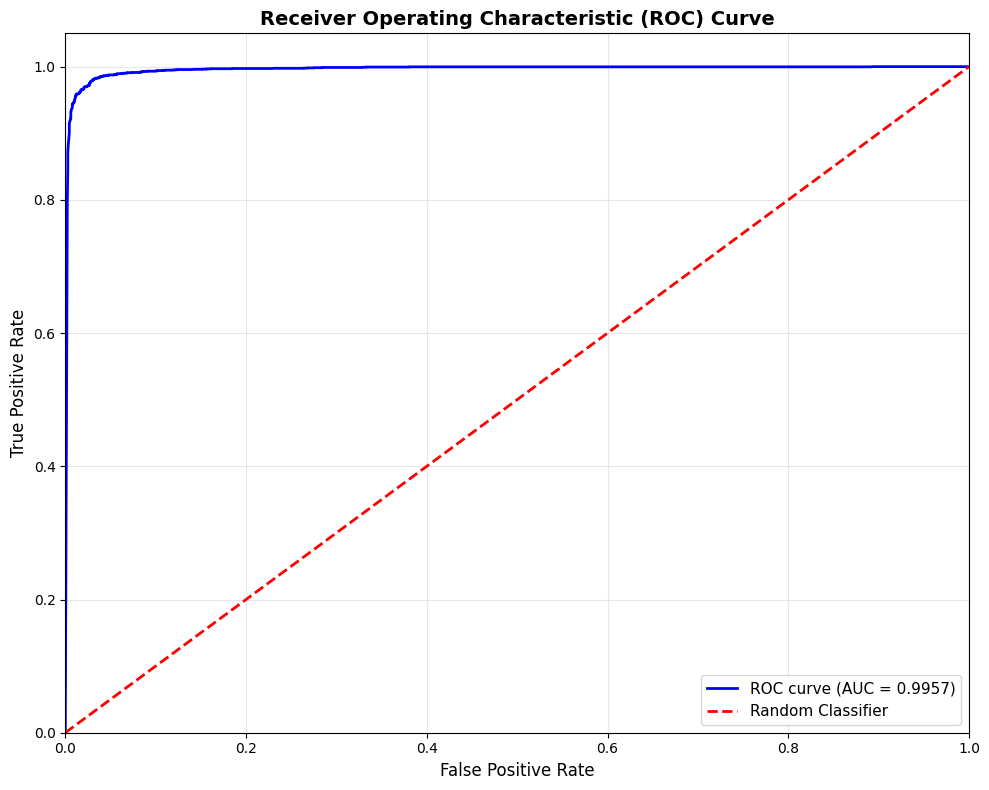

Confusion matrix saved to: confusion_matrix.png


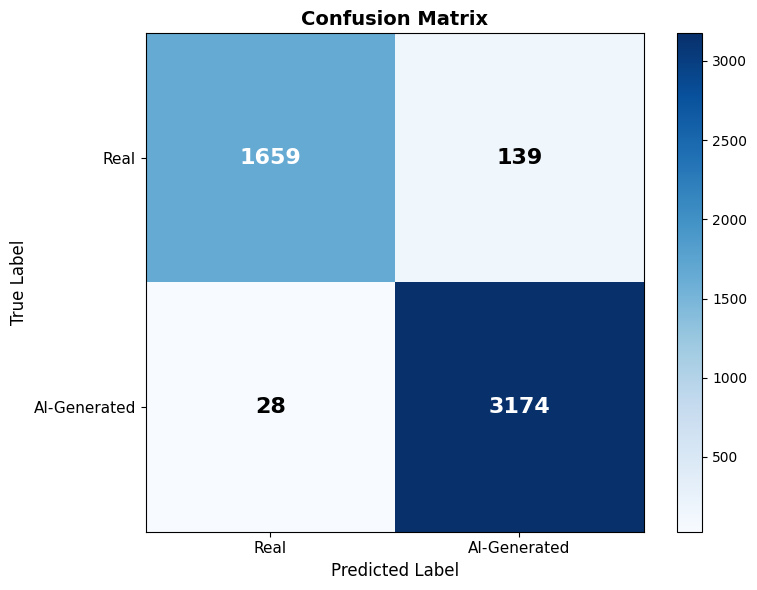


Metrics saved to: model_metrics.csv

Metrics Summary:
 accuracy  precision   recall  f1_score  roc_auc  specificity  true_negatives  false_positives  false_negatives  true_positives
   0.9666   0.958044 0.991255  0.974367 0.995715     0.922692            1659              139               28            3174


In [39]:
# Visualize ROC Curve and Save Metrics

import matplotlib.pyplot as plt

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(labels, probs_positive)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
print("ROC curve saved to: roc_curve.png")
plt.show()

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Real', 'AI-Generated'], fontsize=11)
plt.yticks(tick_marks, ['Real', 'AI-Generated'], fontsize=11)

# Add text annotations
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=16, fontweight='bold')

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Confusion matrix saved to: confusion_matrix.png")
plt.show()

# Save metrics to a file
metrics_dict = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'roc_auc': roc_auc,
    'specificity': specificity,
    'true_negatives': int(tn),
    'false_positives': int(fp),
    'false_negatives': int(fn),
    'true_positives': int(tp)
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_df.to_csv('model_metrics.csv', index=False)
print("\nMetrics saved to: model_metrics.csv")
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))

In [28]:
import os

# Check current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /workspace
